In [4]:
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid
import tensorflow as tf
import os
import pickle


--- Enter the dimensions of Grain D for prediction ---

----------------------------------------
--- Predicted Performance Results (Grain D) ---
----------------------------------------
ISP: 176.90 s
Total Impulse (Model): 125030.73 N.s
Total Impulse (Calculated Area): 127103.95 N.s
Burn Time: 20.85 s
Max Thrust: 9699.02 N
----------------------------------------



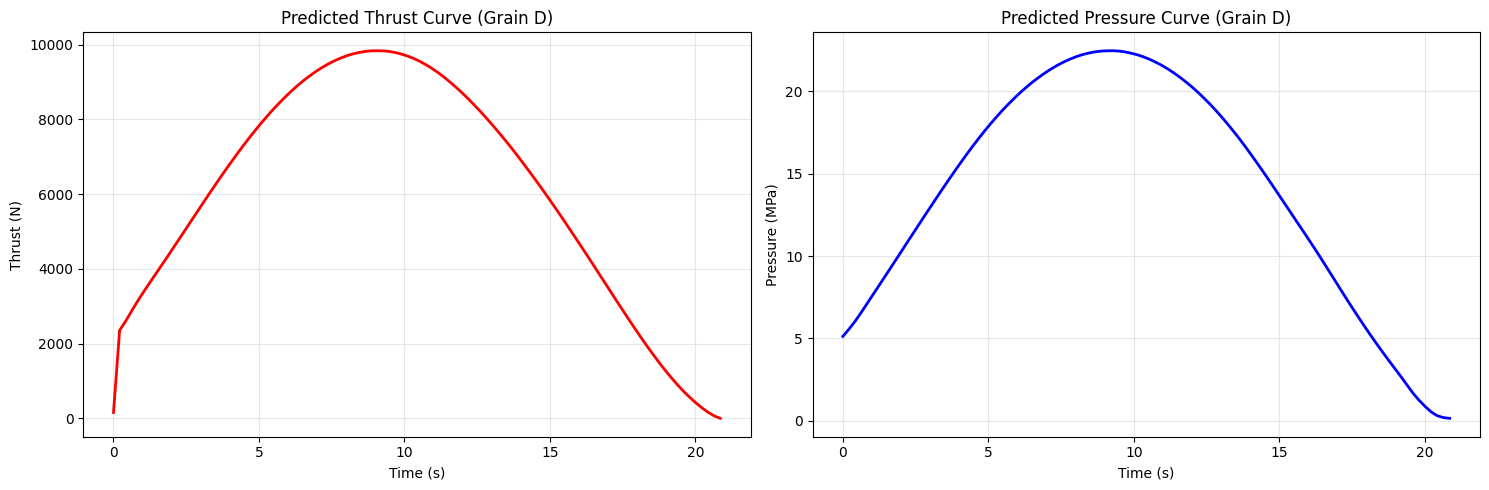

In [6]:

MODEL_PATH = r"grain_d_model.keras"
SCALAR_SCALER_PATH = r"grain_d_scalers.pkl"

# Load model
model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

# Load scalers
with open(SCALAR_SCALER_PATH, 'rb') as f:
    scalers = pickle.load(f)

s_X  = scalers['s_X']
s_yt = scalers['s_yt']
s_yp = scalers['s_yp']
s_ys = scalers['s_ys']

def get_user_input_and_predict_grain_d():
    print("\n" + "="*50)
    print("--- Enter the dimensions of Grain D for prediction ---")
    print("="*50)
    try:
        # 1. استلام المدخلات الصحيحة لنموذج Grain D
        l_val = float(input("Length: "))
        d_val = float(input("Diameter: "))
        so_val = float(input("Slot Offset: "))
        t_d_val = float(input("Throat Diameter: "))
        e_d_val = float(input("Exit Diameter: "))
        
        # ترتيب المدخلات لنموذج Grain D لتتطابق مع INPUT_COLS
        user_inputs = np.array([[l_val, d_val, so_val, t_d_val, e_d_val]])
        user_inputs_scaled = s_X.transform(user_inputs)
        
        # 2. Prediction
        preds = model.predict(user_inputs_scaled, verbose=0)
        
        # 3. فك التشفير
        thrust_pred = s_yt.inverse_transform(preds[0])
        pressure_pred = s_yp.inverse_transform(preds[1])
        scalars_pred = s_ys.inverse_transform(preds[2])
        
        # 4. استخراج القيم الأربعة 
        isp = scalars_pred[0][0]
        predicted_impulse = scalars_pred[0][1]
        burn_time = scalars_pred[0][2]
        max_thrust = scalars_pred[0][3]
        
        # Preparing the timeline
        time_steps = np.linspace(0, burn_time, 100)
        
        # حساب المساحة تحت المنحنى باستخدام trapezoid
        calculated_impulse = np.trapezoid(thrust_pred[0], time_steps)        
        
        print("\n" + "-"*40)
        print("--- Predicted Performance Results (Grain D) ---")
        print("-"*40)
        print(f"ISP: {isp:.2f} s")
        print(f"Total Impulse (Model): {predicted_impulse:.2f} N.s")
        print(f"Total Impulse (Calculated Area): {calculated_impulse:.2f} N.s")
        print(f"Burn Time: {burn_time:.2f} s")
        print(f"Max Thrust: {max_thrust:.2f} N")
        print("-"*40 + "\n")
        
        # رسم النتائج (بدون فلاتر تنعيم للحفاظ على الشكل الفيزيائي الحقيقي للمنحنى)
        plt.figure(figsize=(15, 5))
        
        # (Thrust Plot)
        plt.subplot(1, 2, 1)
        plt.plot(time_steps, thrust_pred[0], color='red', linewidth=2)
        plt.title('Predicted Thrust Curve (Grain D)')
        plt.xlabel('Time (s)')
        plt.ylabel('Thrust (N)')
        plt.grid(True, alpha=0.3)
        
        # (Pressure Plot)  
        plt.subplot(1, 2, 2)
        plt.plot(time_steps, pressure_pred[0], color='blue', linewidth=2) 
        plt.title('Predicted Pressure Curve (Grain D)')
        plt.xlabel('Time (s)')
        plt.ylabel('Pressure (MPa)')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
      
    except ValueError:
        print("\n[Error]: Please enter valid numeric values.")
    except Exception as e:
        print(f"\n[Error]: An unexpected error occurred: {e}")

# استدعاء الدالة لتشغيل الواجهة
get_user_input_and_predict_grain_d()